In [7]:
# Import packages
# Pour la mnipulation des donnees
import numpy as np
import pandas as pd

# pour la visiualisation des donnees
import matplotlib.pyplot as plt

# Pour l'affichage entier des colonnes
pd.set_option('display.max_columns', None)

# Pour la modelisation
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Pour les metriaues et autres fonction utiles
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# Pour la sauvegarde..
import pickle

In [8]:
%pip install seaborn
import seaborn as sns

In [10]:
df0=pd.read_csv('HR_synthese_dataset.csv')

In [11]:
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [12]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


In [13]:
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [14]:
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [15]:
df0=df0.rename(columns={'average_montly_hours':'average_monthly_hours',
                        'Work_accident': 'work_acident',
                        'time_spend_company':'tenure',
                        'Department': 'department'})
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_acident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

In [18]:
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_acident             0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

In [22]:
print(df0.duplicated().sum())

3008


In [35]:
# df0[df0.duplicated()].head()
df0=df0.drop_duplicates()
df0.duplicated().sum()

np.int64(0)

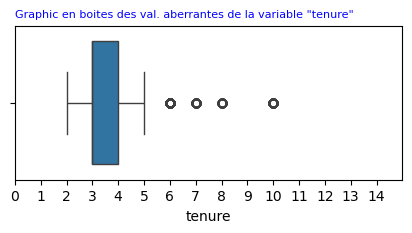

In [47]:
# Ploter les valeurs aberrantes de la colonne 'tenure'
plt.figure(figsize=(5,2))
plt.title('Graphic en boites des val. aberrantes de la variable "tenure"', 
          fontsize=8, color='blue', loc='left')
plt.xlim(0,15)
plt.xticks(range(0,15,1))
sns.boxplot(x=df0['tenure'])
plt.show()

In [50]:
q1=df0['tenure'].quantile(0.25)
q3=df0['tenure'].quantile(0.75)
iqr=q3-q1
lim_inf=q1-1.5*iqr
lim_sup=q3+1.5*iqr
print('limite inferieure:', lim_inf)
print('limite superieure:', lim_sup)
val_aberr=df0[(df0['tenure']>lim_sup)|(df0['tenure']<lim_inf)]
print('Nombre de valeurs aberrantes:', len(val_aberr))

limite inferieure: 1.5
limite superieure: 5.5
Nombre de valeurs aberrantes: 824


In [66]:
print(df0['left'].value_counts().to_frame(name='count'))
print()
print((df0['left'].value_counts(normalize=True)*100).round(3).to_frame(name='count'))

      count
left       
0     10000
1      1991

       count
left        
0     83.396
1     16.604


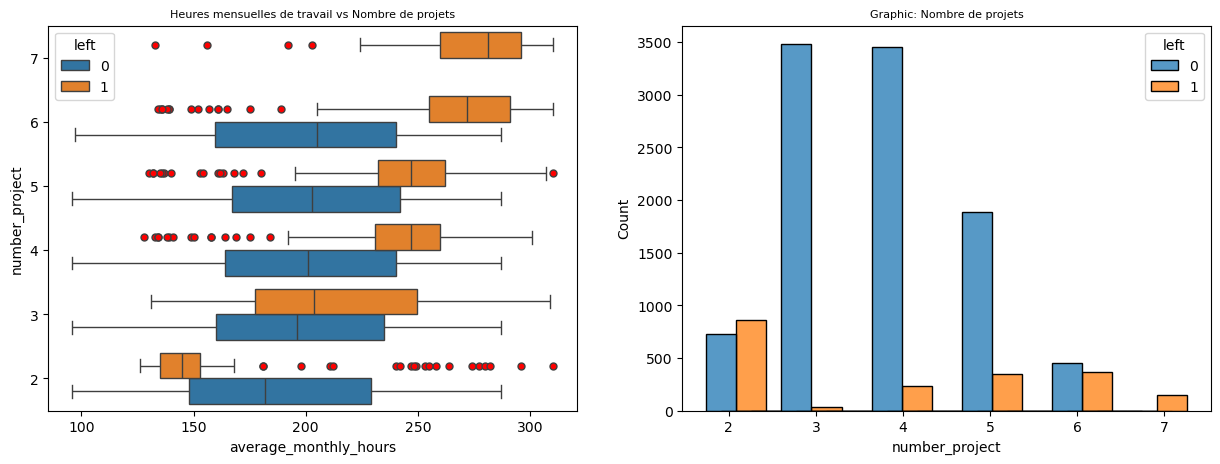

In [80]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.boxplot(data=df0, x='average_monthly_hours', y='number_project',
            hue='left', orient='h', fliersize=5,
            flierprops=dict(marker='o', markerfacecolor='red', 
            markersize=5), ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title("Heures mensuelles de travail vs Nombre de projets", fontsize=8)
# tenure_stay=df0[df0['left']==0]['number_project']
# tenure_left=df0[df0['left']==1]['number_project']
sns.histplot(data=df0, x='number_project', hue='left', multiple='dodge', 
             shrink=4, ax=ax[1])
ax[1].set_title('Graphic: Nombre de projets', fontsize=8)

plt.show()